<a href="https://colab.research.google.com/github/crodriguezbay/MLforMkting/blob/main/SolucionTallerClusteringJerarquico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importa la librería pandas

In [1]:
import pandas as pd

2. Conjunto de datos a analizar en la URL: Carga los datos datos que existen en la url
'https://github.com/ignaciomsarmiento/datasets/raw/refs/heads/main/datos_cliente
s.csv'a Google colab y almacenalos en un dataframe.

In [2]:
url = 'https://github.com/ignaciomsarmiento/datasets/raw/refs/heads/main/datos_clientes.csv'
df = pd.read_csv(url)
display(df.head())

,Id_Cliente,Genero,Edad,Ingreso,Puntaje_Gasto
0,1,Mujer,41,98115.05,39
1,2,Mujer,20,35458.14,75
2,3,Mujer,68,59872.08,55
3,4,Hombre,63,48508.93,51
4,5,Mujer,31,44431.11,54


3. Con la información que vimos la clase pasada, describe los datos: Histogramas,
media, máximo, mínimo, percentiles. Existen datos nulos?

,Id_Cliente,Edad,Ingreso,Puntaje_Gasto
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60624.446600,50.200000
std,57.879185,13.969007,26262.903416,25.823522
min,1.000000,18.000000,13458.020000,1.000000
25%,50.750000,28.750000,41512.787500,34.750000
50%,100.500000,36.000000,60777.960000,50.000000
75%,150.250000,49.000000,77143.865000,73.000000
max,200.000000,70.000000,138584.520000,99.000000



Valores nulos por columna:


,0
Id_Cliente,0
Genero,0
Edad,0
Ingreso,0
Puntaje_Gasto,0



Histogramas de las columnas numéricas:


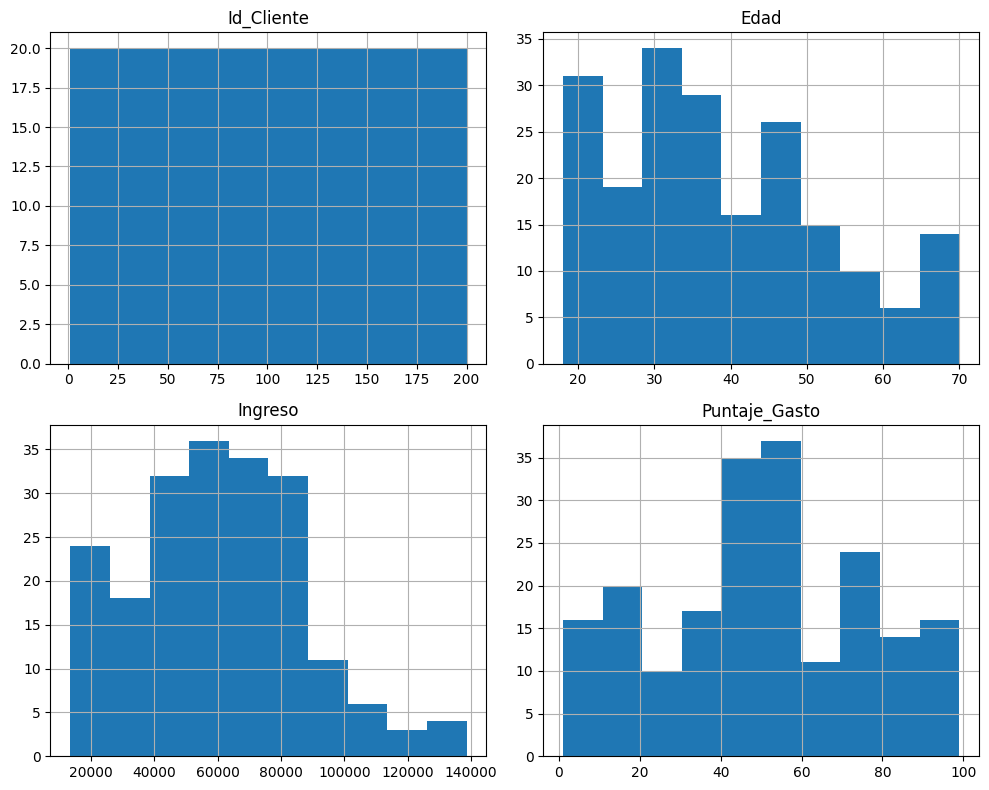

In [3]:
import matplotlib.pyplot as plt

# Display descriptive statistics (media, max, min, percentiles)
display(df.describe())

# Check for null values
print("\nValores nulos por columna:")
display(df.isnull().sum())

# Generate histograms for numerical columns
print("\nHistogramas de las columnas numéricas:")
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id_Cliente     200 non-null    int64  
 1   Genero         200 non-null    object 
 2   Edad           200 non-null    int64  
 3   Ingreso        200 non-null    float64
 4   Puntaje_Gasto  200 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 7.9+ KB


Descripción de la variable categórica 'Genero'

In [5]:
print("Descripción de la variable 'Genero':")
display(df['Genero'].describe())

print("\nConteo de valores únicos para 'Genero':")
display(df['Genero'].value_counts())

Descripción de la variable 'Genero':


,Genero
count,200
unique,2
top,Mujer
freq,112



Conteo de valores únicos para 'Genero':


,count
Genero,
Mujer,112
Hombre,88


4. Genera un nuevo DataFrame que contenga solo las variables de Ingreso y
Puntaje_Gasto del DataFrame principal.

In [6]:
df_selected = df[['Ingreso', 'Puntaje_Gasto']]
display(df_selected.head())

,Ingreso,Puntaje_Gasto
0,98115.05,39
1,35458.14,75
2,59872.08,55
3,48508.93,51
4,44431.11,54


5. Estandariza los datos del nuevo DataFrame utilizando la clase StandardScaler del
módulo sklearn.preprocessing. Almacena el resultado en un nuevo dataframe que se
llame data_scaled.

In [7]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler instance
scaler = StandardScaler()

# Fit and transform the selected data
data_scaled = pd.DataFrame(scaler.fit_transform(df_selected), columns=df_selected.columns)

# Display the head of the scaled data
display(data_scaled.head())

,Ingreso,Puntaje_Gasto
0,1.431094,-0.434801
1,-0.960650,0.962775
2,-0.028719,0.186343
3,-0.462474,0.031057
4,-0.618133,0.147522


6. Construye un dendrograma sobre los datos escalados (data_scaled) utilizando las
funciones linkage y dendrogram de scipy.cluster.hierarchy con el método de enlace
Ward, y muestra la figura con matplotlib.

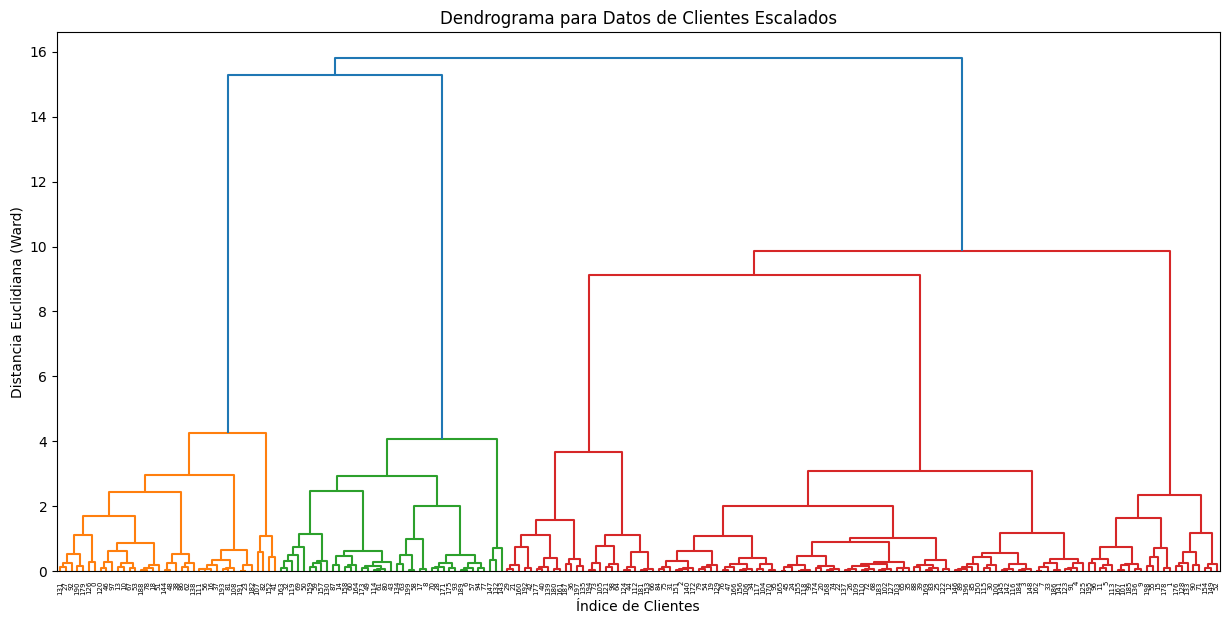

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Generate the linkage matrix
linked = linkage(data_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrograma para Datos de Clientes Escalados')
plt.xlabel('Índice de Clientes')
plt.ylabel('Distancia Euclidiana (Ward)')
plt.show()

7. Genera los segmentos (clusters) en el DataFrame aplicando un corte al
dendrograma con una distancia de 5.

In [10]:
from scipy.cluster.hierarchy import fcluster

# Generate clusters by cutting the dendrogram at a distance of 5
k = 5  # Distance threshold for cutting the dendrogram
clusters = fcluster(linked, k, criterion='distance')

# Add the cluster assignments to the original DataFrame
df['Cluster'] = clusters

# Display the first few rows with the new 'Cluster' column
display(df.head())

# Display the count of observations in each cluster
print("\nConteo de observaciones por cluster:")
display(df['Cluster'].value_counts())

,Id_Cliente,Genero,Edad,Ingreso,Puntaje_Gasto,Cluster
0,1,Mujer,41,98115.05,39,5
1,2,Mujer,20,35458.14,75,1
2,3,Mujer,68,59872.08,55,2
3,4,Hombre,63,48508.93,51,2
4,5,Mujer,31,44431.11,54,2



Conteo de observaciones por cluster:


,count
Cluster,
2,74
4,39
5,38
3,26
1,23


8. Elabora una gráfica de dispersión que muestre el ingreso versus el puntaje gasto de cada uno de los puntos e identifica con colores los puntos de acuerdo al clúster asignado.

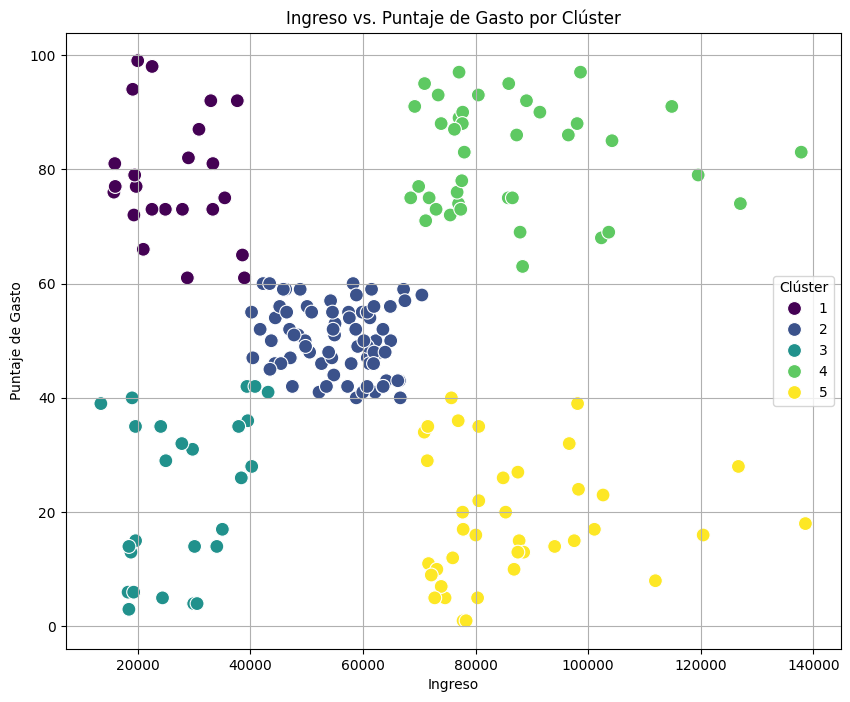

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Ingreso', y='Puntaje_Gasto', hue='Cluster', palette='viridis', s=100)
plt.title('Ingreso vs. Puntaje de Gasto por Clúster')
plt.xlabel('Ingreso')
plt.ylabel('Puntaje de Gasto')
plt.legend(title='Clúster')
plt.grid(True)
plt.show()

9. Calcular la media de cada una de las variables por cada cluster creado
y, comentar el código utilizado junto con la explicación de los pasos
realizados.

In [13]:
# Calcular la media de cada variable por cada cluster
# Agrupamos el DataFrame 'df' por la columna 'Cluster'.
# Luego, seleccionamos solo las columnas numéricas ('Edad', 'Ingreso', 'Puntaje_Gasto') para calcular sus medias por cada cluster.
# 'Id_Cliente' es típicamente un identificador y no es significativo para calcular la media en un contexto de cluster.
cluster_means = df.groupby('Cluster')[['Edad', 'Ingreso', 'Puntaje_Gasto']].mean()

# Calcular el número de observaciones (conteo) dentro de cada cluster
cluster_counts = df['Cluster'].value_counts().rename('Count')

# Unir las medias con los conteos de cada cluster
cluster_summary = cluster_means.join(cluster_counts)

# Mostrar el resumen de los clusters con las medias y los conteos
display(cluster_summary)

,Edad,Ingreso,Puntaje_Gasto,Count
Cluster,,,,
1,25.521739,26230.419565,78.565217,23
2,43.594595,55451.258514,50.216216,74
3,44.115385,28274.667308,23.307692,26
4,32.692308,86537.496410,82.128205,39
5,40.394737,87055.074474,18.631579,38


### Explicación de las Medias y Conteo de los Clusters

El código anterior calcula los valores promedio para 'Edad', 'Ingreso' y 'Puntaje_Gasto' para cada uno de los clusters de clientes identificados, **y también agrega el número de clientes en cada cluster**.

**Pasos Realizados:**
1.  **`df.groupby('Cluster')`**: Esto agrupa el DataFrame `df` basándose en los valores únicos de la columna 'Cluster'. Esto significa que todas las filas que pertenecen al Cluster 1 se agrupan, todas las filas del Cluster 2 se agrupan, y así sucesivamente.
2.  **`[['Edad', 'Ingreso', 'Puntaje_Gasto']]`**: Después de agrupar, seleccionamos las columnas numéricas específicas para las que queremos calcular la media. 'Id_Cliente' se excluye ya que su media no proporcionaría información significativa sobre las características del cluster.
3.  **`.mean()`**: Esta función calcula el valor promedio para cada una de las columnas seleccionadas dentro de cada uno de los clusters definidos previamente, almacenando el resultado en `cluster_means`.
4.  **`df['Cluster'].value_counts().rename('Count')`**: Esto calcula cuántas observaciones (clientes) hay en cada cluster y renombra la serie resultante a 'Count'.
5.  **`cluster_means.join(cluster_counts)`**: Finalmente, unimos el DataFrame de las medias (`cluster_means`) con la serie de conteos (`cluster_counts`) utilizando el índice (que es el número de cluster).

**Propósito:**
Este paso es crucial para **perfilar** cada cluster. Al examinar estos valores medios **y el tamaño de cada cluster**, podemos comprender las características típicas de los clientes dentro de cada segmento. Por ejemplo, un cluster podría tener un ingreso promedio alto y un puntaje de gasto alto, mientras que otro podría tener un ingreso promedio bajo y un puntaje de gasto bajo, lo que ayuda a definir distintas personas de clientes. Además, conocer el tamaño de cada cluster es importante para evaluar la relevancia y el impacto de cada segmento.

10. Agrega y muestra el número de observaciones (conteo) dentro de cada
grupo (cluster) en el resumen anterior.

11. Grafica los promedios de ingreso y puntaje gasto en gráficas de barras de cada uno de los segmentos.

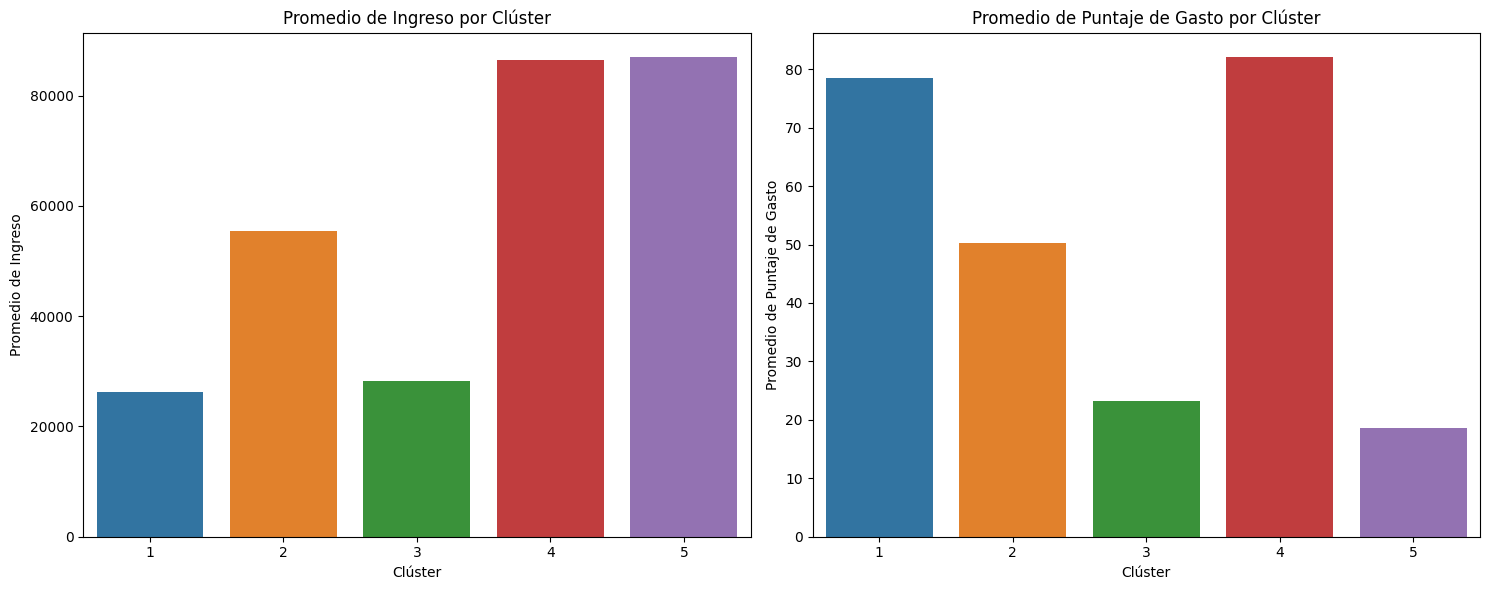

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# Bar plot for 'Ingreso' (Income) by cluster
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x=cluster_summary.index, y='Ingreso', data=cluster_summary, hue=cluster_summary.index, palette='tab10', legend=False)
plt.title('Promedio de Ingreso por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Promedio de Ingreso')

# Bar plot for 'Puntaje_Gasto' (Spending Score) by cluster
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x=cluster_summary.index, y='Puntaje_Gasto', data=cluster_summary, hue=cluster_summary.index, palette='tab10', legend=False)
plt.title('Promedio de Puntaje de Gasto por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Promedio de Puntaje de Gasto')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [15]:
# Generate clusters by cutting the dendrogram at a distance of 5
k = 4  # Distance threshold for cutting the dendrogram
clusters = fcluster(linked, k, criterion='distance')

# Add the cluster assignments to the original DataFrame
df['Cluster'] = clusters

# Display the first few rows with the new 'Cluster' column
display(df.head())

# Display the count of observations in each cluster
print("\nConteo de observaciones por cluster:")
display(df['Cluster'].value_counts())

,Id_Cliente,Genero,Edad,Ingreso,Puntaje_Gasto,Cluster
0,1,Mujer,41,98115.05,39,7
1,2,Mujer,20,35458.14,75,1
2,3,Mujer,68,59872.08,55,2
3,4,Hombre,63,48508.93,51,2
4,5,Mujer,31,44431.11,54,2



Conteo de observaciones por cluster:


,count
Cluster,
2,74
5,36
7,34
3,26
1,23
6,4
4,3


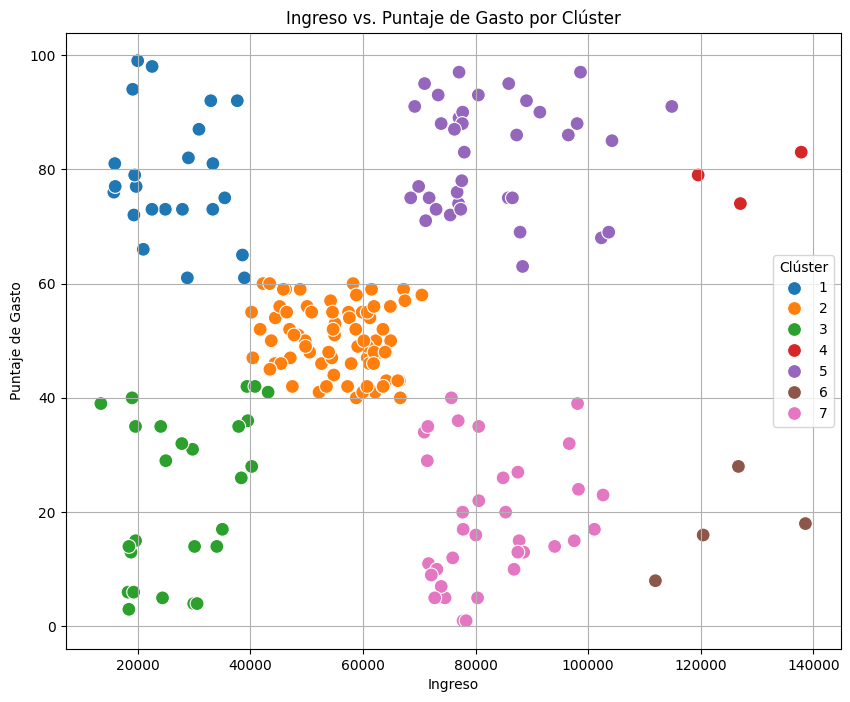

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Ingreso', y='Puntaje_Gasto', hue='Cluster', palette='tab10', s=100)
plt.title('Ingreso vs. Puntaje de Gasto por Clúster')
plt.xlabel('Ingreso')
plt.ylabel('Puntaje de Gasto')
plt.legend(title='Clúster')
plt.grid(True)
plt.show()